First 10 features:
 tensor([[ 1.0382,  0.1247],
        [ 0.1255,  1.4494],
        [-0.3773,  0.0901],
        [ 0.5731, -0.1338],
        [-0.4877,  0.0540],
        [ 1.2314, -1.2405],
        [ 0.2269,  0.3388],
        [ 0.6644, -0.3838],
        [-2.0347, -0.8302],
        [ 1.8575, -0.8959]])

First 10 labels:
 tensor([[ 5.8429],
        [-0.4866],
        [ 3.1411],
        [ 5.7953],
        [ 3.0489],
        [10.8829],
        [ 3.4906],
        [ 6.8424],
        [ 2.9504],
        [10.9692]])


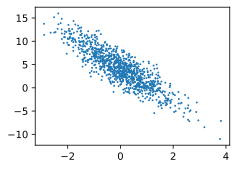

In [10]:
from numpy.ma.core import indices
from sympy import banded
%matplotlib inline
import random
import torch
from d2l import torch as d2l

"创建数据集"
def synthetic_data(w,b,num_examples):
    x=torch.normal(0,1,(num_examples,len(w)))
    y = torch.matmul(x, w) + b
    y += torch.normal(0, 0.01, y.shape)
    return x,y.reshape(-1,1)


true_w=torch.tensor([2,-3.4])
true_b=4.2
features,labels=synthetic_data(true_w,true_b,1000)
# 打印前10个特征
print('First 10 features:\n', features[:10])

# 打印前10个标签
print('\nFirst 10 labels:\n', labels[:10])

d2l.set_figsize()
d2l.plt.scatter(features[:, (1)].detach().numpy(), labels.detach().numpy(), 1);

In [11]:
"读取数据集"
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    # 这些样本是随机读取的，没有特定的顺序
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(
            indices[i: min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]
batch_size = 10

for X, y in data_iter(batch_size, features, labels):
    print(X, '\n', y)
    break

tensor([[ 0.0717, -1.3320],
        [-1.3693, -0.4266],
        [-0.1586, -0.5195],
        [ 0.9596, -1.2945],
        [ 1.2005, -0.1334],
        [-1.0116,  0.3947],
        [ 2.0140,  0.0516],
        [-0.7040,  0.4657],
        [ 0.0769,  0.1750],
        [ 0.1581, -1.7927]]) 
 tensor([[ 8.8887],
        [ 2.9249],
        [ 5.6769],
        [10.5235],
        [ 7.0710],
        [ 0.8330],
        [ 8.0517],
        [ 1.2134],
        [ 3.7615],
        [10.6122]])
